In [1]:
import os
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
                                     Conv2DTranspose, concatenate, 
                                     BatchNormalization, Activation, add)
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow.keras.backend as K
from sklearn.model_selection import KFold

2026-04-06 14:04:29.175574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775484269.202560   12478 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775484269.209785   12478 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775484269.228484   12478 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775484269.228516   12478 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775484269.228519   12478 computation_placer.cc:177] computation placer alr

In [2]:
IMG_HEIGHT = 256  # 
IMG_WIDTH = 256   # 
N_CHANNELS = 1    # Ảnh Grayscale Electron Microscopy 
BATCH_SIZE = 4    # Dataset nhỏ nên Batch size để thấp
EPOCHS = 150      # [cite: 319]
N_SPLITS = 5      # 5-Fold Cross Validation [cite: 335]
LEARNING_RATE = 1e-3
ALPHA = 1.67      # [cite: 201]

# Đường dẫn tập dữ liệu ISBI-2012
base_path = "/kaggle/input/datasets/quanhh42/multiresunet-datasets/ISBI-2012-challenge"
train_vol_path = os.path.join(base_path, "train-volume.tif")
train_lab_path = os.path.join(base_path, "train-labels.tif")

In [3]:
def load_isbi_data(path, is_mask=False):
    success, images = cv2.imreadmulti(path)
    if not success:
        raise ValueError(f"Không thể đọc file tại {path}")
    
    data = []
    for img in images:
        resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        if is_mask:
            # Chuẩn hóa mask nhị phân
            resized = resized / 255.0
            resized = np.round(resized, 0)
        else:
            # Chuẩn hóa ảnh gốc [0, 1] [cite: 299]
            resized = resized / 255.0
        data.append(resized)
    
    return np.expand_dims(np.array(data), axis=-1)

print("Đang nạp tập dữ liệu ISBI-2012...")
X = load_isbi_data(train_vol_path, is_mask=False)
Y = load_isbi_data(train_lab_path, is_mask=True)
print(f"Nạp thành công! X shape: {X.shape}, Y shape: {Y.shape}")

Đang nạp tập dữ liệu ISBI-2012...
Nạp thành công! X shape: (30, 256, 256, 1), Y shape: (30, 256, 256, 1)


In [4]:
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

In [5]:
# A. U-Net Baseline [cite: 89]
def build_unet_baseline(input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)):
    def conv_block(inputs, num_filters):
        x = Conv2D(num_filters, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal')(inputs)
        x = Conv2D(num_filters, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal')(x)
        return x

    inputs = Input(input_shape)
    s1 = conv_block(inputs, 32)
    p1 = MaxPooling2D((2, 2))(s1)
    s2 = conv_block(p1, 64)
    p2 = MaxPooling2D((2, 2))(s2)
    s3 = conv_block(p2, 128)
    p3 = MaxPooling2D((2, 2))(s3)
    s4 = conv_block(p3, 256)
    p4 = MaxPooling2D((2, 2))(s4)
    b5 = conv_block(p4, 512)
    u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(b5)
    c6 = concatenate([u6, s4], axis=3)
    d6 = conv_block(c6, 256)
    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(d6)
    c7 = concatenate([u7, s3], axis=3)
    d7 = conv_block(c7, 128)
    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d7)
    c8 = concatenate([u8, s2], axis=3)
    d8 = conv_block(c8, 64)
    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(d8)
    c9 = concatenate([u9, s1], axis=3)
    d9 = conv_block(c9, 32)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(d9)
    return Model(inputs, outputs, name='UNet_Baseline')

In [6]:
# B. MultiResUNet [cite: 240]
def build_multiresunet(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1), activation='relu'):
        x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding, use_bias=False)(x)
        x = BatchNormalization(axis=3, scale=False)(x)
        if activation is not None: x = Activation(activation)(x)
        return x

    def MultiResBlock(U, inp, alpha=1.67): # [cite: 132]
        W = alpha * U
        shortcut = conv2d_bn(inp, int(W*0.167) + int(W*0.333) + int(W*0.5), 1, 1, activation=None)
        conv3x3 = conv2d_bn(inp, int(W*0.167), 3, 3)
        conv5x5 = conv2d_bn(conv3x3, int(W*0.333), 3, 3)
        conv7x7 = conv2d_bn(conv5x5, int(W*0.5), 3, 3)
        out = concatenate([conv3x3, conv5x5, conv7x7], axis=3)
        out = BatchNormalization(axis=3)(out)
        out = add([shortcut, out])
        out = Activation('relu')(out)
        return BatchNormalization(axis=3)(out)

    def ResPath(filters, length, inp): # [cite: 188]
        shortcut = conv2d_bn(inp, filters, 1, 1, activation=None)
        out = conv2d_bn(inp, filters, 3, 3)
        out = add([shortcut, out])
        out = Activation('relu')(out)
        out = BatchNormalization(axis=3)(out)
        for _ in range(length - 1):
            shortcut = conv2d_bn(out, filters, 1, 1, activation=None)
            out = conv2d_bn(out, filters, 3, 3)
            out = add([shortcut, out])
            out = Activation('relu')(out)
            out = BatchNormalization(axis=3)(out)
        return out

    inputs = Input((height, width, n_channels))
    mres1 = MultiResBlock(32, inputs)
    pool1 = MaxPooling2D((2, 2))(mres1)
    res1 = ResPath(32, 4, mres1)
    mres2 = MultiResBlock(64, pool1)
    pool2 = MaxPooling2D((2, 2))(mres2)
    res2 = ResPath(64, 3, mres2)
    mres3 = MultiResBlock(128, pool2)
    pool3 = MaxPooling2D((2, 2))(mres3)
    res3 = ResPath(128, 2, mres3)
    mres4 = MultiResBlock(256, pool3)
    pool4 = MaxPooling2D((2, 2))(mres4)
    res4 = ResPath(256, 1, mres4)
    
    mres5 = MultiResBlock(512, pool4) # Bottleneck
    
    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(mres5), res4], axis=3)
    mres6 = MultiResBlock(256, up6)
    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(mres6), res3], axis=3)
    mres7 = MultiResBlock(128, up7)
    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(mres7), res2], axis=3)
    mres8 = MultiResBlock(64, up8)
    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(mres8), res1], axis=3)
    mres9 = MultiResBlock(32, up9)
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(mres9)
    return Model(inputs, outputs, name='MultiResUNet')

In [7]:
def train_and_evaluate(build_fn, model_name, X, Y, kf):
    """
    Hàm huấn luyện và đánh giá mô hình sử dụng 5-Fold Cross Validation[cite: 335].
    Thực hiện huấn luyện cố định 150 epoch và lưu lại kết quả tốt nhất[cite: 319, 342].
    """
    os.makedirs(f'models_{model_name}', exist_ok=True)
    # Khởi tạo nhật ký để lưu kết quả tổng hợp từ các Fold [cite: 337]
    metrics_log = {'jaccard': [], 'dice': [], 'histories': []}
    best_overall_fold = 0
    best_val_jac = 0

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"\n--- {model_name.upper()} | Fold {fold}/{N_SPLITS} ---")
        # Xóa session cũ để giải phóng bộ nhớ GPU
        K.clear_session()
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        model = build_fn()
        # Sử dụng Adam optimizer và hàm mất mát Binary Cross-Entropy [cite: 305, 313]
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=[jacard, dice_coef] # Các độ đo đánh giá chuẩn [cite: 325, 330]
        )

        # Đường dẫn lưu trọng số (đổi tên thành ISBI để phân biệt)
        path = f'models_{model_name}/{model_name}_isbi_fold{fold}_best.weights.h5'
        
        # Lưu kết quả tốt nhất đạt được trên tập Validation trong suốt 150 epoch 
        checkpoint = ModelCheckpoint(
            path, monitor='val_jacard', mode='max', 
            save_best_only=True, save_weights_only=True, verbose=0
        )

        # Huấn luyện cố định 150 epoch, không dùng Early Stopping theo thiết kế bài báo 
        history = model.fit(
            X_train, Y_train, 
            validation_data=(X_val, Y_val), 
            batch_size=BATCH_SIZE, 
            epochs=EPOCHS, 
            callbacks=[checkpoint], 
            verbose=0 # Tắt log để giao diện sạch sẽ
        )
        
        metrics_log['histories'].append(history)
        # Ghi lại giá trị cao nhất đạt được trong suốt quá trình huấn luyện của Fold này [cite: 342]
        max_jac_fold = max(history.history['val_jacard'])
        max_dic_fold = max(history.history['val_dice_coef'])
        
        metrics_log['jaccard'].append(max_jac_fold)
        metrics_log['dice'].append(max_dic_fold)
        
        print(f"Kết quả Fold {fold}: Jaccard = {max_jac_fold*100:.2f}% | Dice = {max_dic_fold*100:.2f}%")
        
        # Cập nhật Fold tốt nhất để phục vụ việc vẽ Demo Comparison sau này
        if max_jac_fold > best_val_jac:
            best_val_jac = max_jac_fold
            best_overall_fold = fold

    return metrics_log, best_overall_fold

In [8]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=3)
unet_results, unet_best_fold = train_and_evaluate(build_unet_baseline, 'unet', X, Y, kf)
multi_results, multi_best_fold = train_and_evaluate(build_multiresunet, 'multiresunet', X, Y, kf)


--- UNET | Fold 1/5 ---


I0000 00:00:1775484280.021969   12478 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1775484286.418371   12535 service.cc:152] XLA service 0x79c70800a400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775484286.418421   12535 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775484287.600210   12535 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-06 14:04:49.675808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 14:04:49.909551: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accurac

Kết quả Fold 1: Jaccard = 89.08% | Dice = 94.22%

--- UNET | Fold 2/5 ---
Kết quả Fold 2: Jaccard = 88.78% | Dice = 94.06%

--- UNET | Fold 3/5 ---
Kết quả Fold 3: Jaccard = 88.09% | Dice = 93.67%

--- UNET | Fold 4/5 ---
Kết quả Fold 4: Jaccard = 90.06% | Dice = 94.77%

--- UNET | Fold 5/5 ---
Kết quả Fold 5: Jaccard = 89.01% | Dice = 94.19%

--- MULTIRESUNET | Fold 1/5 ---
Kết quả Fold 1: Jaccard = 89.83% | Dice = 94.64%

--- MULTIRESUNET | Fold 2/5 ---
Kết quả Fold 2: Jaccard = 89.45% | Dice = 94.43%

--- MULTIRESUNET | Fold 3/5 ---
Kết quả Fold 3: Jaccard = 88.33% | Dice = 93.80%

--- MULTIRESUNET | Fold 4/5 ---
Kết quả Fold 4: Jaccard = 90.03% | Dice = 94.75%

--- MULTIRESUNET | Fold 5/5 ---
Kết quả Fold 5: Jaccard = 89.57% | Dice = 94.50%


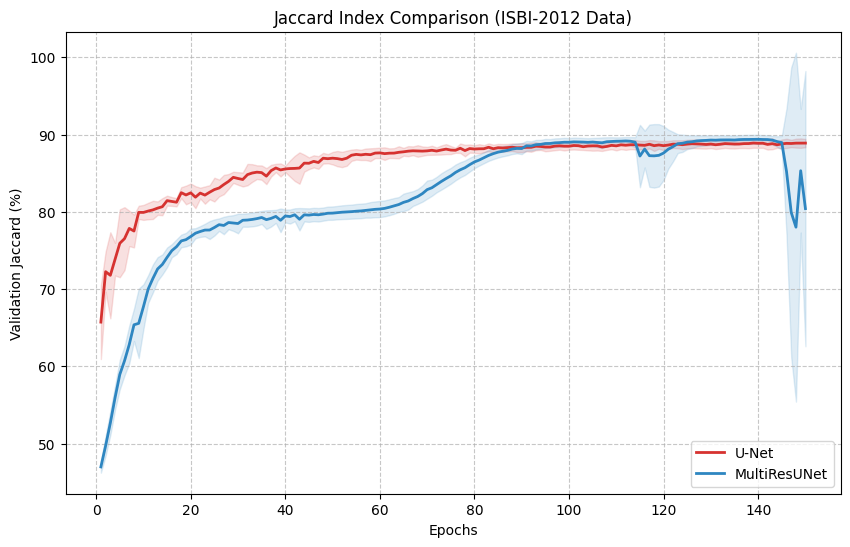

2026-04-06 14:34:24.909975: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 14:34:25.144860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


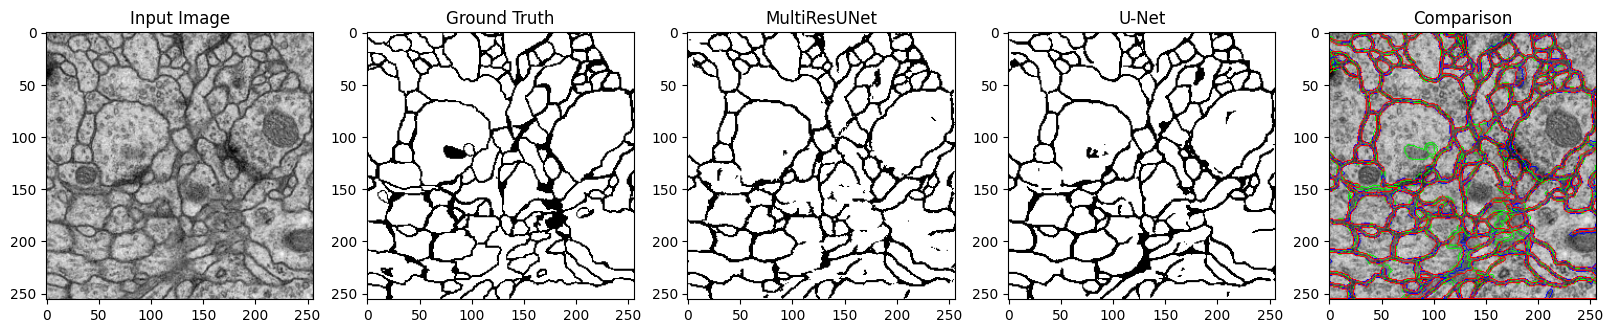

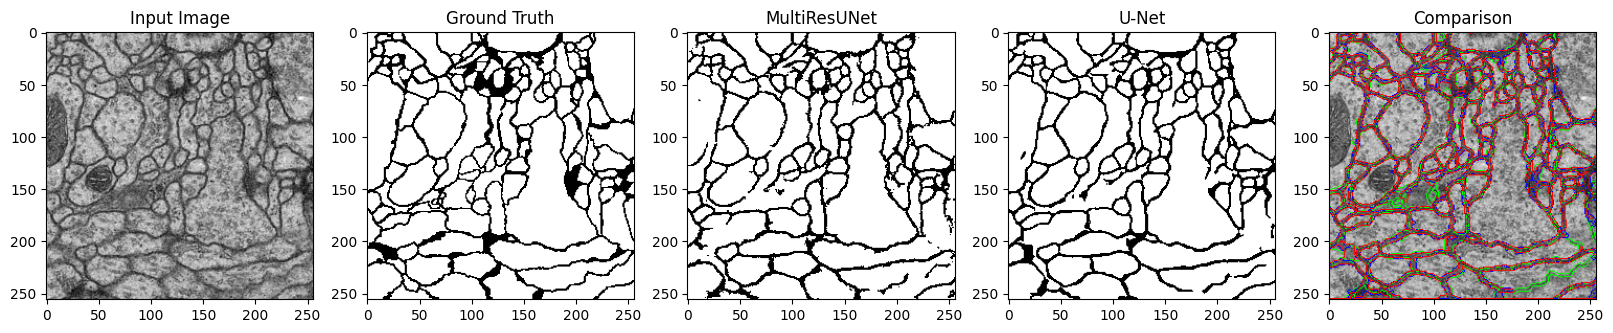

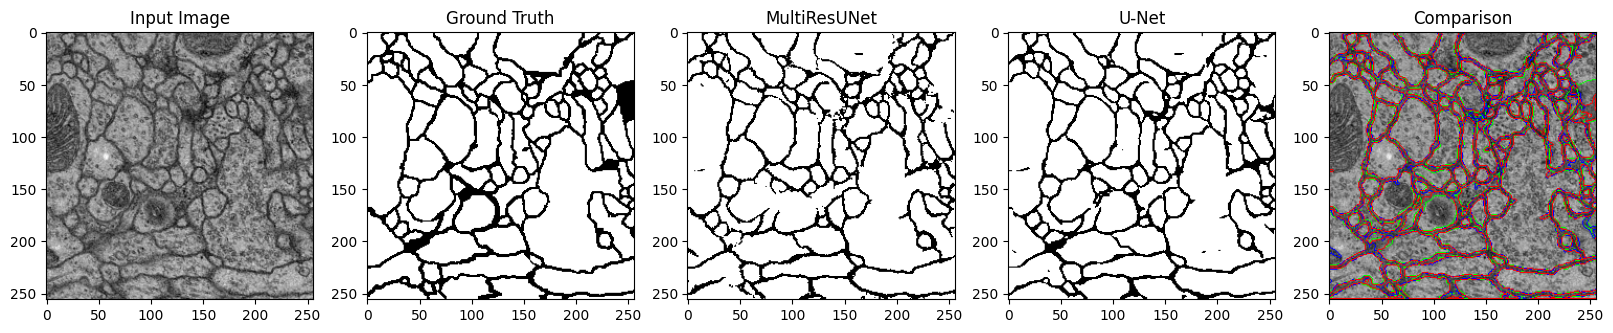


✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH!


In [9]:
# --- 6. TRỰC QUAN HÓA (PAPER-STYLE) ---

def plot_paper_curves(unet_hist, multi_hist):
    unet_data = np.array([h.history['val_jacard'] for h in unet_hist]) * 100
    multi_data = np.array([h.history['val_jacard'] for h in multi_hist]) * 100
    epochs = np.arange(1, unet_data.shape[1] + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, np.mean(unet_data, axis=0), label='U-Net', color='#D63230', linewidth=2)
    plt.fill_between(epochs, np.mean(unet_data, axis=0) - np.std(unet_data, axis=0), 
                     np.mean(unet_data, axis=0) + np.std(unet_data, axis=0), color='#D63230', alpha=0.15)
    
    plt.plot(epochs, np.mean(multi_data, axis=0), label='MultiResUNet', color='#2E86C1', linewidth=2)
    plt.fill_between(epochs, np.mean(multi_data, axis=0) - np.std(multi_data, axis=0), 
                     multi_data.mean(axis=0) + multi_data.std(axis=0), color='#2E86C1', alpha=0.15)

    plt.title('Jaccard Index Comparison (ISBI-2012 Data)')
    plt.xlabel('Epochs'), plt.ylabel('Validation Jaccard (%)')
    plt.grid(True, linestyle='--', alpha=0.7), plt.legend(loc='lower right')
    plt.savefig('ISBI2012_Learning_Curve.png', dpi=300), plt.show()

def draw_contour(img, mask, color):
    mask_u8 = (mask.squeeze() * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_c = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    cv2.drawContours(img_c, contours, -1, color, 1)
    return img_c

def show_demo(best_fold_idx):
    train_idx, val_idx = list(kf.split(X))[best_fold_idx - 1]
    X_val, Y_val = X[val_idx], Y[val_idx]
    
    m_unet = build_unet_baseline()
    m_unet.load_weights(f'models_unet/unet_isbi_fold{best_fold_idx}_best.weights.h5')
    m_multi = build_multiresunet()
    m_multi.load_weights(f'models_multiresunet/multiresunet_isbi_fold{best_fold_idx}_best.weights.h5')
    
    p_u = np.round(m_unet.predict(X_val, verbose=0), 0)
    p_m = np.round(m_multi.predict(X_val, verbose=0), 0)
    
    for i in range(3): # Show top 3 samples
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        axes[0].imshow(X_val[i], cmap='gray'), axes[0].set_title("Input Image")
        axes[1].imshow(Y_val[i], cmap='gray'), axes[1].set_title("Ground Truth")
        axes[2].imshow(p_m[i], cmap='gray'), axes[2].set_title("MultiResUNet")
        axes[3].imshow(p_u[i], cmap='gray'), axes[3].set_title("U-Net")
        
        comp = draw_contour(X_val[i], Y_val[i], (0, 255, 0)) # GT: Green
        comp = draw_contour(cv2.cvtColor(comp, cv2.COLOR_RGB2GRAY)/255.0, p_m[i], (0, 0, 255)) # Multi: Blue
        # (Redraw properly for final overlap display)
        comp = cv2.cvtColor((X_val[i] * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        cv2.drawContours(comp, cv2.findContours((Y_val[i]*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], -1, (0,255,0), 1)
        cv2.drawContours(comp, cv2.findContours((p_m[i]*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], -1, (0,0,255), 1)
        cv2.drawContours(comp, cv2.findContours((p_u[i]*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], -1, (255,0,0), 1)
        
        axes[4].imshow(comp), axes[4].set_title("Comparison")
        plt.show()

# Xuất kết quả cuối cùng
plot_paper_curves(unet_results['histories'], multi_results['histories'])
show_demo(multi_best_fold)

# Nén dữ liệu tải về
!zip -q -r ISBI2012_Results.zip models_multiresunet/ models_unet/ *.png
print("\n✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH!")

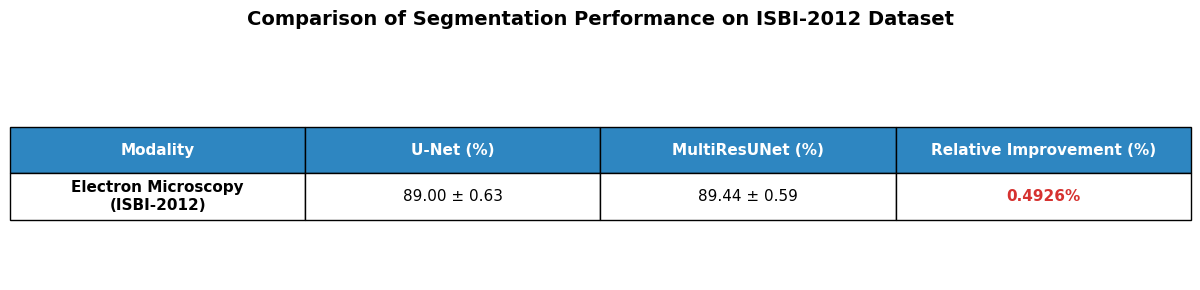

✅ Đã cập nhật bảng báo cáo! Chỉ số cải thiện: 0.4926%


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Trích xuất và tính toán thông số từ kết quả huấn luyện (trong RAM)
u_jac_mean = np.mean(unet_results['jaccard']) * 100
u_jac_std  = np.std(unet_results['jaccard']) * 100
m_jac_mean = np.mean(multi_results['jaccard']) * 100
m_jac_std  = np.std(multi_results['jaccard']) * 100

# Công thức tính Relative Improvement (%) theo bài báo 
rel_improvement = ((m_jac_mean - u_jac_mean) / u_jac_mean) * 100

# 2. Chuẩn bị dữ liệu theo cấu trúc Table 4 của bài báo 
# Cột: Modality | U-Net (%) | MultiResUNet (%) | Relative Improvement (%)
columns = ("Modality", "U-Net (%)", "MultiResUNet (%)", "Relative Improvement (%)")
data = [
    [
        "Electron Microscopy\n(ISBI-2012)", 
        f"{u_jac_mean:.2f} ± {u_jac_std:.2f}", 
        f"{m_jac_mean:.2f} ± {m_jac_std:.2f}", 
        f"{rel_improvement:.4f}%"
    ]
]

# 3. Vẽ bảng bằng Matplotlib
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

# Tạo bảng với định dạng cellLoc='center' để canh giữa toàn bộ
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')

# Tùy chỉnh font và kích thước để giống văn bản học thuật
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 3) # Kéo dãn chiều cao hàng để nhìn thoáng hơn

# Đổ màu Header và định dạng chữ đậm cho các mốc quan trọng
for (row, col), cell in table.get_celld().items():
    if row == 0: # Dòng tiêu đề
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2E86C1') # Màu xanh đặc trưng MultiResUNet
    if row > 0:
        if col == 0 or col == 3: # Cột tên Dataset hoặc cột Improvement
            cell.set_text_props(weight='bold')
        if col == 3: # Highlight cột Improvement
            cell.set_text_props(color='#D63230') # Màu đỏ để gây chú ý

plt.title('Comparison of Segmentation Performance on ISBI-2012 Dataset', 
          fontsize=14, pad=30, fontweight='bold')

plt.tight_layout()
plt.savefig('ISBI2012_Official_Style_Table.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Đã cập nhật bảng báo cáo! Chỉ số cải thiện: {rel_improvement:.4f}%")

In [ ]:
import os
from IPython.display import FileLink

# 1. Tên file nén đầu ra
zip_filename = 'Ket_Qua_Nghiên_Cuu_ISBI2012.zip'

# 2. Dọn dẹp file cũ nếu tồn tại để giải phóng bộ nhớ
if os.path.exists(zip_filename):
    os.remove(zip_filename)

print(f"--- Đang bắt đầu đóng gói kết quả ---")

# 3. Sử dụng lệnh zip của Linux để nén đích danh:
# - models_multiresunet/ và models_unet/: Chứa toàn bộ weights (.h5) của 5-Fold
# - *.png: Chứa toàn bộ biểu đồ Learning Curve, K-Fold, Table và Demo Comparison
# - *.pkl: Chứa dữ liệu history (nếu có lưu) để vẽ lại biểu đồ sau này
!zip -q -r {zip_filename} models_multiresunet/ models_unet/ *.png *.pkl

print(f"✅ Đã nén xong toàn bộ dữ liệu!")
print(f"Bạn hãy click vào đường link bên dưới để tải file về máy:")

# 4. Hiển thị link tải trực tiếp
display(FileLink(zip_filename))

--- Đang bắt đầu đóng gói kết quả ---


In [10]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_paper_learning_curve(unet_histories, multi_histories, metric='val_jacard', title_metric='Validation Jaccard (%)'):
#     """
#     Hàm móc dữ liệu từ lịch sử huấn luyện 5-Fold và vẽ biểu đồ so sánh có bóng mờ (Variance)
#     Đã đảo thứ tự Legend: U-Net nằm trên, MultiResUNet nằm dưới
#     """
#     print("Đang trích xuất dữ liệu và vẽ biểu đồ...")
    
#     # 1. Trích xuất dữ liệu của 5 Folds (Chuyển sang dạng phần trăm %)
#     unet_data = np.array([h.history[metric] for h in unet_histories]) * 100
#     multi_data = np.array([h.history[metric] for h in multi_histories]) * 100
    
#     # Lấy mốc trục X là số Epochs (1 đến 150)
#     epochs = np.arange(1, unet_data.shape[1] + 1)
    
#     # 2. Tính Trung bình (Mean) và Độ lệch chuẩn (Std)
#     unet_mean = np.mean(unet_data, axis=0)
#     unet_std = np.std(unet_data, axis=0)
    
#     multi_mean = np.mean(multi_data, axis=0)
#     multi_std = np.std(multi_data, axis=0)
    
#     # 3. Tiến hành vẽ biểu đồ
#     plt.figure(figsize=(10, 6))
    
#     # VẼ U-NET TRƯỚC ĐỂ LÊN TOP LEGNED (Đường màu Đỏ)
#     plt.plot(epochs, unet_mean, label='U-Net', color='#D63230', linewidth=2)
#     plt.fill_between(epochs, 
#                      unet_mean - unet_std, 
#                      unet_mean + unet_std, 
#                      color='#D63230', alpha=0.2, linewidth=0)

#     # VẼ MULTIRESUNET SAU ĐỂ NẰM DƯỚI LEGEND (Đường màu Xanh dương)
#     plt.plot(epochs, multi_mean, label='MultiResUNet', color='#2E86C1', linewidth=2)
#     plt.fill_between(epochs, 
#                      multi_mean - multi_std, 
#                      multi_mean + multi_std, 
#                      color='#2E86C1', alpha=0.2, linewidth=0)
    
    
#     # 4. Trang trí biểu đồ chuẩn bài báo (Paper-style)
#     plt.title('Jaccard Index Comparison (CVC-ClinicDB Data)', fontsize=14)
#     plt.xlabel('Epochs', fontsize=12)
#     plt.ylabel(title_metric, fontsize=12)
    
#     # Lưới kẻ (Grid) mờ
#     plt.grid(True, linestyle='--', alpha=0.7)
    
#     # Ghi chú (Legend) ở góc dưới bên phải
#     plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
    
#     # Giới hạn trục Y và X cho đẹp mắt
#     plt.xlim(0, len(epochs) + 5)
    
#     plt.tight_layout()
#     plt.savefig('Paper_Style_Learning_Curve.png', dpi=300, bbox_inches='tight')
#     plt.show()
#     print("Đã lưu biểu đồ thành công: 'Paper_Style_Learning_Curve.png'")

# # ============================================================================
# # GỌI HÀM VẼ BIỂU ĐỒ 
# # ============================================================================
# # Vẽ cho Jaccard Index
# plot_paper_learning_curve(unet_histories, multi_histories, metric='val_jacard', title_metric='Validation Jaccard (%)')

# # Nếu muốn vẽ thêm cho Dice thì bạn bỏ dấu '#' ở dòng dưới nha:
# # plot_paper_learning_curve(unet_histories, multi_histories, metric='val_dice_coef', title_metric='Validation Dice (%)')

In [11]:
# import os
# from IPython.display import FileLink

# print("1. Đang dọn dẹp file ZIP bị lỗi để giải phóng ổ cứng...")
# # Xóa file ZIP rác khổng lồ (nếu có)
# if os.path.exists('/kaggle/working/Backup_Models_CVC.zip'):
#     os.remove('/kaggle/working/Backup_Models_CVC.zip')

# print("2. Đang nén lại dữ liệu (Tốc độ bàn thờ bằng Linux)...")
# # Dùng lệnh zip của Linux nén đích danh các thư mục và file cần thiết (bỏ qua file ẩn rác)
# !zip -q -r Backup_Models_CVC.zip models_multiresunet/ models_unet/ *.png *.pkl

# print("✅ Đã giải cứu ổ cứng và nén xong! Click vào link bên dưới để tải:")
# display(FileLink('Backup_Models_CVC.zip'))